**Welcome to pyLIMA (v2) tutorial 2!**

This second tutorial will give you some basics about how to reconfigure your input parameters.

If you do not like the standard pyLIMA parameters, this is made for you. We will demonstrate how to
replace them with parameters of your choice using the fancy_parameters module.

We are going to fit the same light curves as in tutorial 1, but using different parametrization.

In [1]:
### First import the required libraries as before.
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
from pyLIMA.fits import TRF_fit
from pyLIMA.models import FSPL_model
### Import fancy_parameters. This will allow us to change the definitions as required.
from pyLIMA.models import pyLIMA_fancy_parameters
from pyLIMA.outputs import pyLIMA_plots

from pyLIMA import event
from pyLIMA import telescopes

fancy_parameters already provides some commonly used options, for example:

In [2]:
# pyLIMA_fancy_parameters.standard_fancy_parameters
pyLIMA_fancy_parameters.StandardFancyParameters().fancy_parameters
# pyLIMA_fancy_parameters.StandardFancyParameters().fancy_boundaries

{'tE': 'log_tE',
 'rho': 'log_rho',
 'separation': 'log_separation',
 'mass_ratio': 'log_mass_ratio'}

Begin by create a new EVENT object and giving it a name, as in example 1.

In [3]:
your_event = event.Event()
your_event.name = 'My event name'

Associate some data sets with this **EVENT**. 

Again, you will use simulated I-band data sets from two telescopes, OGLE and LCO.

The data sets are pre-formatted: column 1 is the date, column 2 the magnitude and column 3 the uncertainty in the magnitude.

Load up the data:

In [4]:
data_1 = np.loadtxt('./data/Survey_1.dat')
telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt('./data/Followup_1.dat')
telescope_2 = telescopes.Telescope(name = 'LCO', 
                                   camera_filter = 'I',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

Append these two telescope data sets to your EVENT object.

In [5]:
your_event.telescopes.append(telescope_1)
your_event.telescopes.append(telescope_2)

Define the survey telescope that you want to use to align all other data sets to.

We recommend using the data set with the most measurements covering the gretest 
time span of observations:

In [6]:
your_event.find_survey('OGLE')

Run a quick sanity check on your input.

In [7]:
your_event.check_event()

check_event  : Everything looks fine...


If necessary, set the microlensing limb-darkening coefficients (gamma) for each telescope.

We already saw in example 1 that setting limb darkening coefficients improves the fit for this event, so we set them again:

In [8]:
your_event.telescopes[0].ld_gamma = 0.5
your_event.telescopes[1].ld_gamma = 0.5

Define the model and fit method (as in example 1) and let it know that you will be using alternative parameters.

To do this, set the option fancy_parameters when you define the model. We will replace just one parameter, tE with log_tE.

In essence, we need to define a transformation function within pyLIMA.

For this particular transformation, i.e. from tE to log(tE), pyLIMA already provides the necessary functions to convert back and forth: 

In [9]:
my_pars = pyLIMA_fancy_parameters.StandardFancyParameters() 
my_pars.fancy_parameters = {'tE': 'log_tE'}
print(my_pars.fancy_parameters)
print(my_pars.fancy_boundaries)
fspl = FSPL_model.FSPLmodel(your_event, fancy_parameters=my_pars)

{'tE': 'log_tE'}
{'log_tE': (0, 3), 'log_rho': (-5, -1.3), 'log_separation': (-1, 1), 'log_mass_ratio': (-5, 0)}


We now want to fit this FSPL model to the data using the Trust Region Reflective (TRF) algorithm, but we have set it to use different parameters for the fit. 

Instead of tE, we have now set it to use log_tE.

We can make this faster by using the results we obtained in example 1: [t0, u0, tE, rho] = [79.9, 0.008, 10.1, 0.023]. 

Since the results in example 1 were given in the standard format, we need to adjust them so they match the new definition.

In [10]:
guess_parameters = [79.9, 0.008, np.log10(10.1), 0.023]

Import the TRF fitting algorithm and fit:

In [11]:
my_fit = TRF_fit.TRFfit(fspl)
my_fit.model_parameters_guess = guess_parameters
my_fit.fit()

initial_guess  : Initial parameters guess SUCCESS
Using guess:  [79.9, 0.008, 1.0043213737826426, 0.023, 2953.360297238239, 3123.3732636938903, 99641.49723043977, 112148.63494684835]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(79.93092278168737)),
             ('u0', np.float64(0.008144756760153467)),
             ('log_tE', np.float64(1.0047831732586028)),
             ('rho', np.float64(0.02259885634945231)),
             ('fsource_OGLE', np.float64(2917.6485943026737)),
             ('ftotal_OGLE', np.float64(3125.891542175063)),
             ('fsource_LCO', np.float64(92640.68800033553)),
             ('ftotal_LCO', np.float64(141827.3849583538)),
             ('chi2', np.float64(3851.0557798626783))])


Let's see the plot. Zoom close to the peak again to see what is going on.

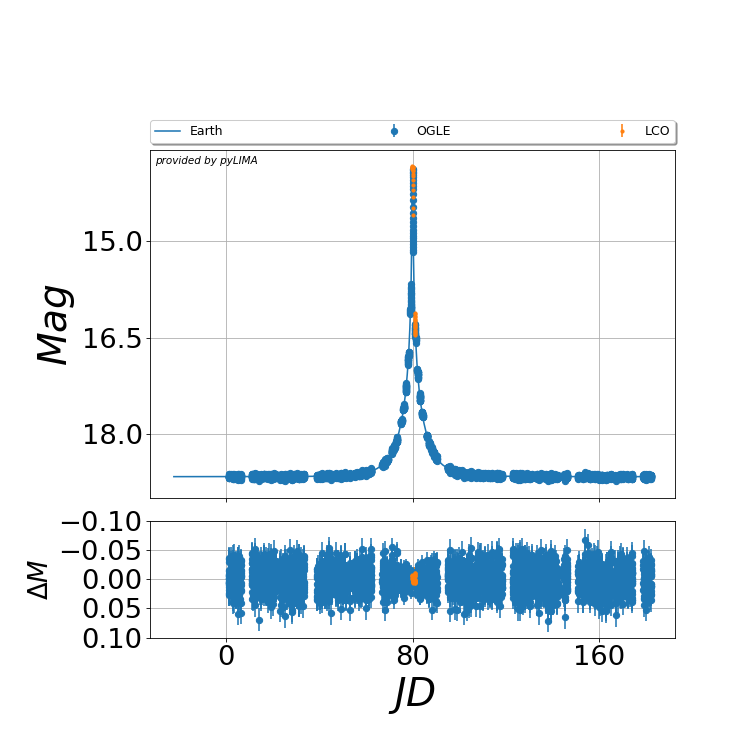

In [12]:
pyLIMA_plots.plot_lightcurves(fspl, my_fit.fit_results['best_model'])
plt.show()

So this works as expected! 

OK, let's try something more complicated now: define t_star = rho*tE and use log_rho = log(rho).

The log_rho definition is already provided by pyLIMA, but t_star isn't. 

So we need to tell pyLIMA what kind of changes we want by defining them:

Define the transformation from t_star --> t_E. This uses the default parameterisation.


In [13]:
def t_star(x):
    return x.rho * x.tE

setattr(pyLIMA_fancy_parameters, 't_star', t_star)

It is also necessary to define the inverse transformation from t_E --> t_star.

Note that the inverse transformation needs to be defined using the new parameterisation!

In [14]:
def tE(x):
    return x.t_star/10**(x.log_rho)

setattr(pyLIMA_fancy_parameters, 'tE', tE)

Your new t_star definition is now part of fancy_parameters and you can use it.

In [15]:
dir(pyLIMA_fancy_parameters)

['StandardFancyParameters',
 'StandardFancyParameters2',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_t0_to_t_center',
 '_t_center_to_t0',
 '_u0_to_u_center',
 '_u_center_to_u0',
 'np',
 'tE',
 't_star']

Update the fancy parameter dictionary with the new definitions:

In [19]:
my_pars2 = pyLIMA_fancy_parameters.StandardFancyParameters() 
my_pars2.fancy_parameters = {'rho':'log_rho', 't_star':'t_star'}
fspl2 = FSPL_model.FSPLmodel(your_event,fancy_parameters=my_pars2)

I skip the fancy parameter t_star, as it is not part of model FSPL


Give it the guess parameters we obtained from example 1, formatted using the new definitions.

t_star = rho * tE so in our example that is 10.1 * 0.023:

In [20]:
guess_parameters2 = [79.9, 0.008, 10.1 * 0.023, np.log10(0.023)]

Perform the fit using the new parameter definitions:

In [21]:
my_fit2 = TRF_fit.TRFfit(fspl2)
my_fit2.model_parameters_guess = guess_parameters2
my_fit2.fit()

initial_guess  : Initial parameters guess SUCCESS
Using guess:  [79.9, 0.008, 0.23229999999999998, -1.6382721639824072, 128634.05722941757, 3367.4110739656608, 422823.692202185, 980022.9804973616]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(79.96375907964105)),
             ('u0', np.float64(0.01108534129203281)),
             ('tE', np.float64(9.607642910674965)),
             ('log_rho', np.float64(-2.892184439115813)),
             ('fsource_OGLE', np.float64(3153.142090606861)),
             ('ftotal_OGLE', np.float64(3129.3928814274936)),
             ('fsource_LCO', np.float64(106080.18782050272)),
             ('ftotal_LCO', np.float64(58980.145241585844)),
             ('chi2', np.float64(8440.061585983287))])


To call all standard plotting options you can optionally use the fit_outputs module. 

If you want just the light curve, you can use plot_lightcurves as in example 1.

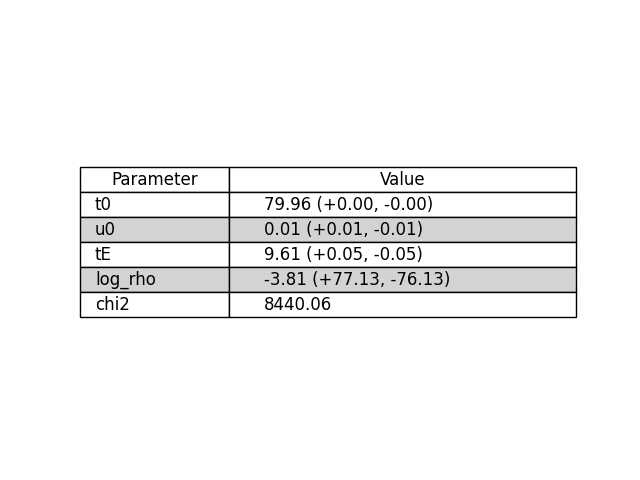

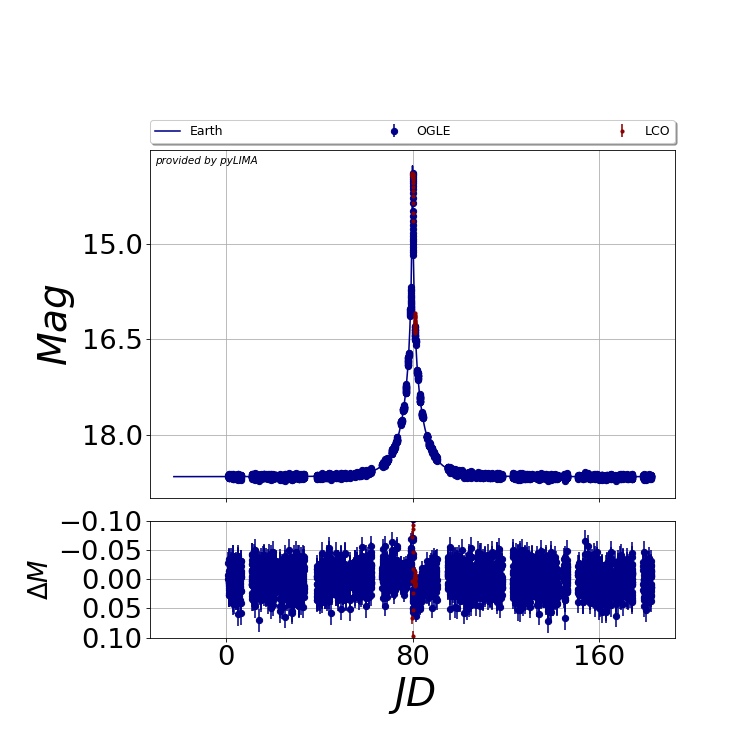

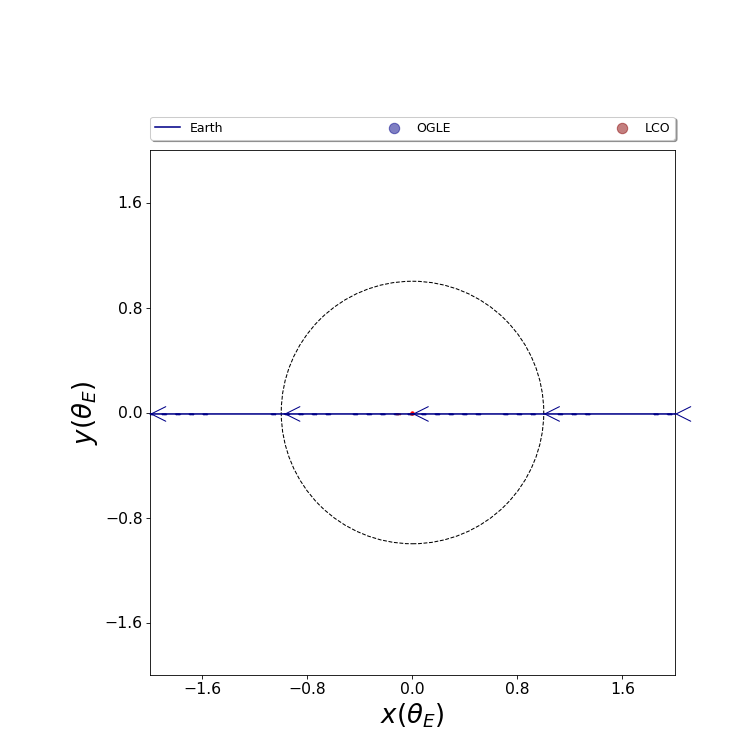

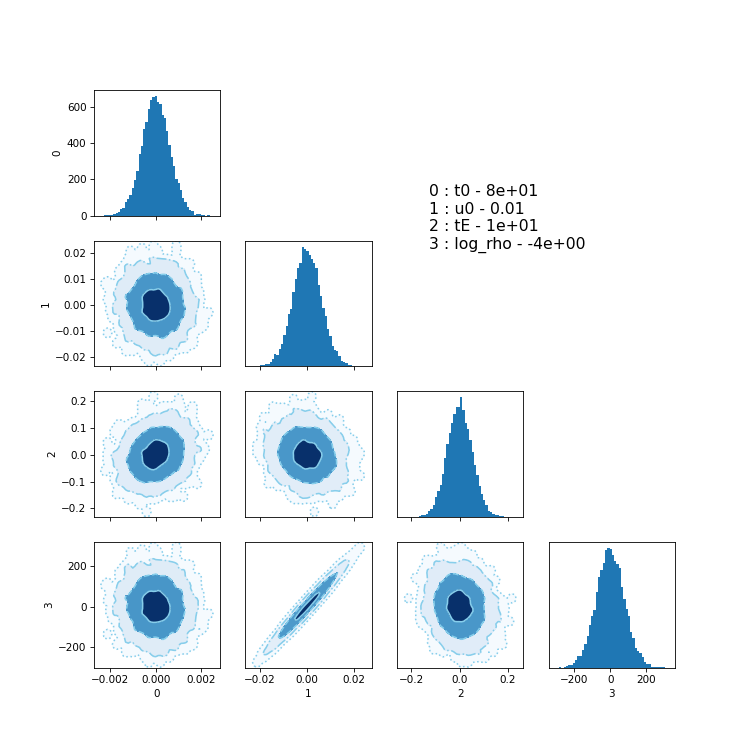

In [22]:
my_fit2.fit_outputs()
plt.show()

Let's look at the optimized parameters and the $\chi^2$ of the fit:

In [23]:
print("fit results: ", my_fit2.fit_results['best_model'])
print("chi2: ", my_fit2.fit_results['chi2'])

fit results:  [ 7.99637591e+01  1.10853413e-02  9.60764291e+00 -2.89218444e+00
  3.15314209e+03  3.12939288e+03  1.06080188e+05  5.89801452e+04]
chi2:  8440.061585983287


If you have forgotten the order of the parameters, do:

In [24]:
my_fit2.fit_parameters.keys()

odict_keys(['t0', 'u0', 'tE', 'log_rho', 'fsource_OGLE', 'ftotal_OGLE', 'fsource_LCO', 'ftotal_LCO'])

Note that the results now are displayed with our newly defined parameters.

This concludes tutorial 2.